In [131]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import community.community_louvain as community_louvain
from collections import Counter
import ast
import random
import matplotlib.cm as cm
import matplotlib.patches as mpatches

np.random.seed(42)

In [132]:
df_tweets = pd.read_csv('data/tweets.csv')
df_users = pd.read_csv('data/users.csv')

In [133]:
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203451 entries, 0 to 203450
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                195386 non-null  float64
 1   user_key               203451 non-null  object 
 2   created_at             203430 non-null  float64
 3   created_str            203430 non-null  object 
 4   retweet_count          58052 non-null   float64
 5   retweeted              58052 non-null   object 
 6   favorite_count         58052 non-null   float64
 7   text                   203430 non-null  object 
 8   tweet_id               201137 non-null  float64
 9   source                 58053 non-null   object 
 10  hashtags               203451 non-null  object 
 11  expanded_urls          203451 non-null  object 
 12  posted                 203451 non-null  object 
 13  mentions               203451 non-null  object 
 14  retweeted_status_id    39649 non-nul

In [134]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                392 non-null    float64
 1   location          284 non-null    object 
 2   name              383 non-null    object 
 3   followers_count   383 non-null    float64
 4   statuses_count    383 non-null    float64
 5   time_zone         368 non-null    object 
 6   verified          383 non-null    object 
 7   lang              383 non-null    object 
 8   screen_name       453 non-null    object 
 9   description       338 non-null    object 
 10  created_at        383 non-null    object 
 11  favourites_count  383 non-null    float64
 12  friends_count     383 non-null    float64
 13  listed_count      383 non-null    float64
dtypes: float64(6), object(8)
memory usage: 49.7+ KB


In [135]:
df_tweets["tweet_id"] = df_tweets["tweet_id"].astype("Int64")
df_tweets["user_id"] = df_tweets["user_id"].astype("Int64")
df_users["id"] = df_users["id"].astype("Int64")
df_tweets["created_at_dt"] = pd.to_datetime(df_tweets["created_str"], errors="coerce")

In [136]:
df_tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203451 entries, 0 to 203450
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                195386 non-null  Int64         
 1   user_key               203451 non-null  object        
 2   created_at             203430 non-null  float64       
 3   created_str            203430 non-null  object        
 4   retweet_count          58052 non-null   float64       
 5   retweeted              58052 non-null   object        
 6   favorite_count         58052 non-null   float64       
 7   text                   203430 non-null  object        
 8   tweet_id               201137 non-null  Int64         
 9   source                 58053 non-null   object        
 10  hashtags               203451 non-null  object        
 11  expanded_urls          203451 non-null  object        
 12  posted                 203451 non-null  obje

In [137]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                392 non-null    Int64  
 1   location          284 non-null    object 
 2   name              383 non-null    object 
 3   followers_count   383 non-null    float64
 4   statuses_count    383 non-null    float64
 5   time_zone         368 non-null    object 
 6   verified          383 non-null    object 
 7   lang              383 non-null    object 
 8   screen_name       453 non-null    object 
 9   description       338 non-null    object 
 10  created_at        383 non-null    object 
 11  favourites_count  383 non-null    float64
 12  friends_count     383 non-null    float64
 13  listed_count      383 non-null    float64
dtypes: Int64(1), float64(5), object(8)
memory usage: 50.1+ KB


In [138]:
df = df_tweets.merge(
    df_users,
    left_on="user_key",
    right_on="screen_name",
    how="left"
)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203451 entries, 0 to 203450
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                195386 non-null  Int64         
 1   user_key               203451 non-null  object        
 2   created_at_x           203430 non-null  float64       
 3   created_str            203430 non-null  object        
 4   retweet_count          58052 non-null   float64       
 5   retweeted              58052 non-null   object        
 6   favorite_count         58052 non-null   float64       
 7   text                   203430 non-null  object        
 8   tweet_id               201137 non-null  Int64         
 9   source                 58053 non-null   object        
 10  hashtags               203451 non-null  object        
 11  expanded_urls          203451 non-null  object        
 12  posted                 203451 non-null  obje

## Retweet network of users

In [140]:
# removing empty retweets
rt = df_tweets[df_tweets["retweeted_status_id"].notna()].copy()

In [141]:
rt["retweeter"] = rt["user_key"]
rt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39649 entries, 4 to 203444
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   user_id                39597 non-null  Int64         
 1   user_key               39649 non-null  object        
 2   created_at             39649 non-null  float64       
 3   created_str            39649 non-null  object        
 4   retweet_count          37973 non-null  float64       
 5   retweeted              37973 non-null  object        
 6   favorite_count         37973 non-null  float64       
 7   text                   39649 non-null  object        
 8   tweet_id               39649 non-null  Int64         
 9   source                 37973 non-null  object        
 10  hashtags               39649 non-null  object        
 11  expanded_urls          39649 non-null  object        
 12  posted                 39649 non-null  object        
 13  menti

In [142]:
# lookup: tweet_id -> user_key
tweet_to_user = (
    df_tweets
    .dropna(subset=["tweet_id"])
    .drop_duplicates(subset=["tweet_id"])
    .set_index("tweet_id")["user_key"]
)


print(tweet_to_user.head())

# map retweeted tweet to original author
rt["original_author"] = rt["retweeted_status_id"].map(tweet_to_user)

tweet_id
836227891897651200          kathiemrr
765198948239810560     traceyhappymom
616002306572746752      evewebster373
776693302926147584        blacktolive
777594647875059712    jacquelinisbest
Name: user_key, dtype: object


In [143]:
rt["original_author"].isna().mean()

0.9411838886226639

In [144]:
rt = rt.dropna(subset=["original_author"])
rt = rt[rt["retweeter"] != rt["original_author"]]

In [145]:
# defining edges

edges = (
    rt
    .groupby(["retweeter", "original_author"])
    .size()
    .reset_index(name="weight")
)

In [146]:
edges

,retweeter,original_author,weight
0,_billy_moyer_,westernwindwes,1
1,_nickluna_,cookncooks,3
2,_nickluna_,emileewaren,1
3,_nickluna_,evagreen69,1
4,_nickluna_,garrettsimpson_,3
...,...,...,...
720,worldofhashtags,danageezus,16
721,worldofhashtags,dannythehappies,1
722,worldofhashtags,giselleevns,8
723,worldofhashtags,holycrapchrix,1


In [147]:
G = nx.DiGraph()

for _, row in edges.iterrows():
    G.add_edge(
        row["retweeter"],
        row["original_author"],
        weight=row["weight"]
    )

In [148]:
# pruning

MIN_WEIGHT = 3
G = nx.DiGraph(
    (u, v, d) for u, v, d in G.edges(data=True)
    if d["weight"] >= MIN_WEIGHT
)

In [149]:
# node attributes

user_attrs = (
    df_users
    .set_index("screen_name")
    [["followers_count", "friends_count", "statuses_count", "lang", "time_zone"]]
    .to_dict(orient="index")
)

nx.set_node_attributes(G, user_attrs)

In [150]:
# top 10 most-retweeted user

sorted(
    G.in_degree(weight="weight"),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('ten_gop', 206),
 ('notritahart', 101),
 ('tpartynews', 95),
 ('giselleevns', 85),
 ('daileyjadon', 69),
 ('cassieweltch', 57),
 ('queenofthewo', 51),
 ('kathiemrr', 48),
 ('jasper_fly', 46),
 ('pamela_moore13', 46)]

In [151]:
# top 10 retweeting users

sorted(
    G.out_degree(weight="weight"),
    key=lambda x: x[1],
    reverse=True
)[:10]

[('giselleevns', 134),
 ('melvinsroberts', 93),
 ('rightnpr', 84),
 ('realten_gop', 81),
 ('tpartynews', 71),
 ('puredavie', 54),
 ('traceyhappymom', 52),
 ('kathiemrr', 50),
 ('queenofthewo', 49),
 ('cassieweltch', 43)]

In [152]:
# centrality

pr = nx.pagerank(G, weight="weight")
nx.set_node_attributes(G, pr, "pagerank")

in_deg = dict(G.in_degree(weight="weight"))
nx.set_node_attributes(G, in_deg, "in_degree")

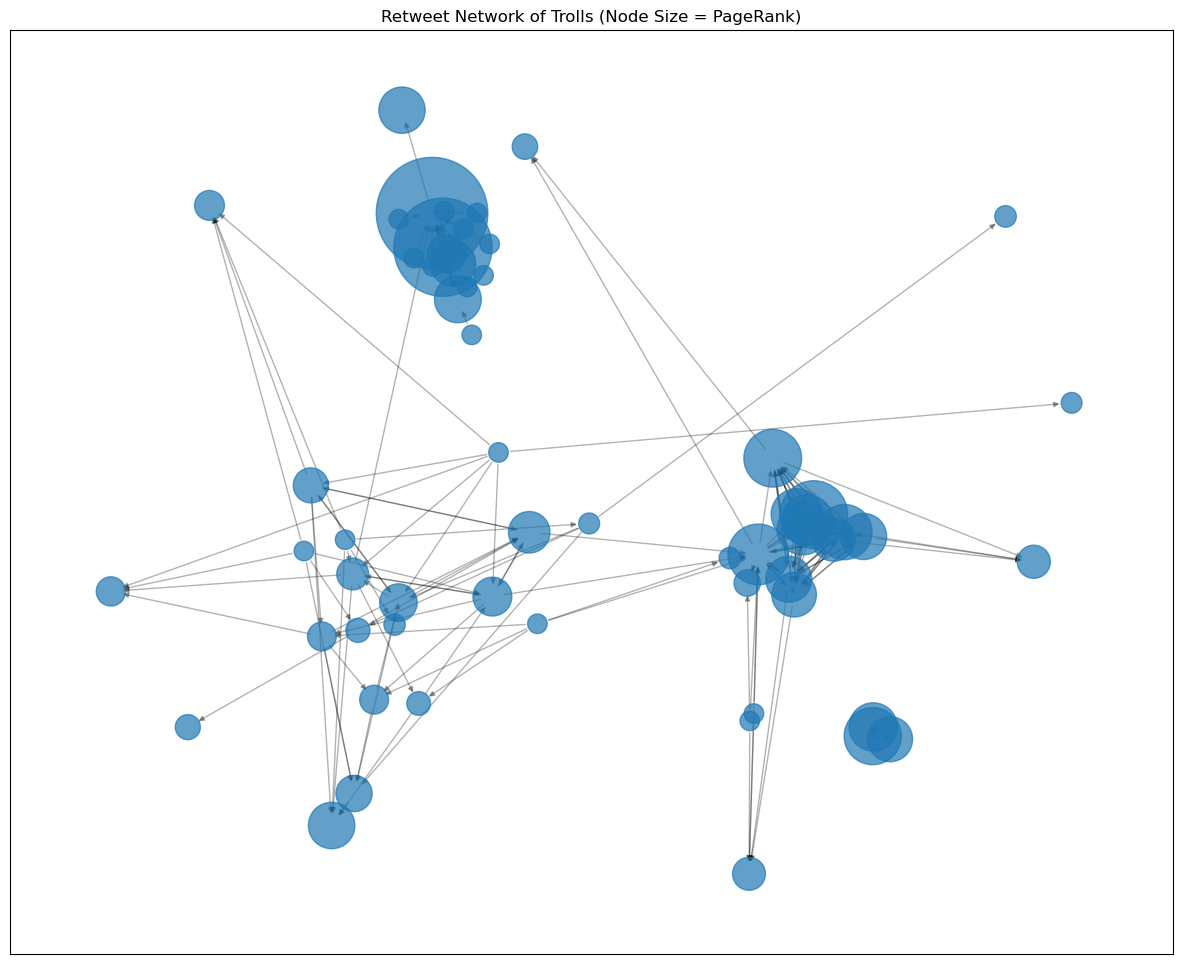

In [158]:
pos = nx.spring_layout(G, k=0.2, seed=42)

# node sizes proportional to PageRank
sizes = [G.nodes[n].get("pagerank", 0) * 50000 for n in G.nodes]

plt.figure(figsize=(15,12))
nx.draw_networkx_nodes(G, pos, node_size=sizes, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrowsize=8)

top_nodes = sorted(
    G.nodes(data=True),
    key=lambda x: x[1].get("pagerank", 0),
    reverse=True
)[:10]


plt.title("Retweet Network of Trolls (Node Size = PageRank)")
plt.show()

In [159]:
nx.write_gexf(G, "retweet_network.gexf")

In [161]:
# community detection

undirected = G.to_undirected()
partition = community_louvain.best_partition(undirected)

nx.set_node_attributes(G, partition, "community")

Counter(partition.values())

Counter({3: 23, 0: 18, 1: 13, 2: 4, 4: 3})

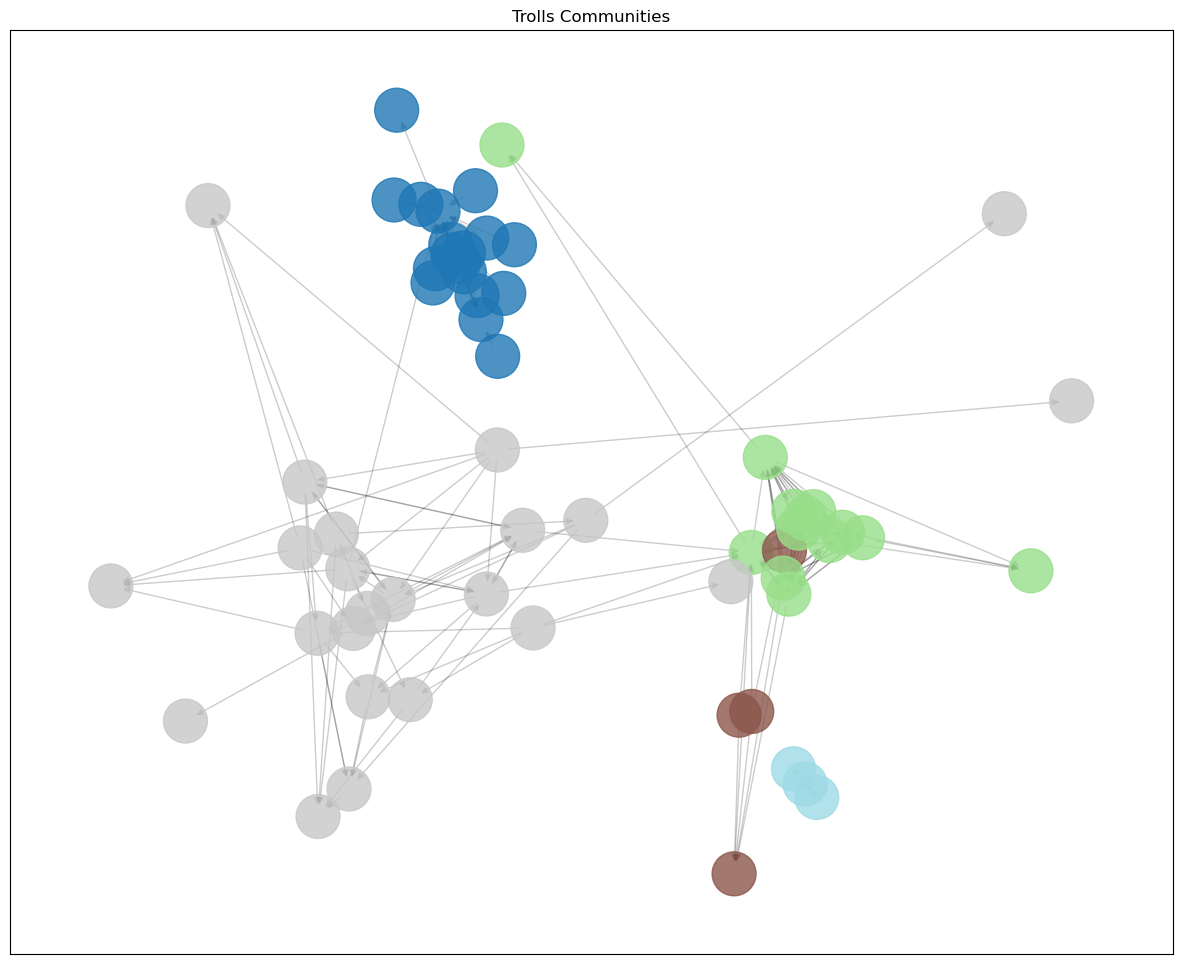

In [166]:
plt.figure(figsize=(15,12))
pos = nx.spring_layout(G, k=0.25, seed=42)

communities = [G.nodes[n]["community"] for n in G.nodes]
nx.draw_networkx_nodes(
    G, pos,
    node_color=communities,
    node_size=1000,
    cmap=plt.cm.tab20,
    alpha=0.8
)


nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Trolls Communities")
plt.show()

In [167]:
nodes_df = pd.DataFrame({
    "user_key": list(G.nodes),
    "community": [G.nodes[n]["community"] for n in G.nodes]
})

In [168]:
nodes_df["community"].unique() # 5 communities detected

array([3, 1, 2, 0, 4], dtype=int64)

In [170]:
user_metrics = pd.DataFrame({
    "user_key": list(G.nodes),
    "pagerank": [G.nodes[n].get("pagerank", 0) for n in G.nodes],
    "in_degree": [G.in_degree(n, weight="weight") for n in G.nodes],
    "out_degree": [G.out_degree(n, weight="weight") for n in G.nodes],
    "total_degree": [G.degree(n, weight="weight") for n in G.nodes]
})

# merge community info
user_metrics = user_metrics.merge(
    pd.DataFrame.from_dict(nx.get_node_attributes(G, 'community'), orient='index', columns=['community']),
    left_on="user_key",
    right_index=True
)

def community_aggregations(df):
    agg = df.groupby("community").agg(
        size=("user_key", "count"),
        avg_in_degree=("in_degree", "mean"),
        avg_out_degree=("out_degree", "mean"),
        avg_total_degree=("total_degree", "mean"),
        median_in_degree=("in_degree", "median"),
        median_out_degree=("out_degree", "median"),
        avg_pagerank=("pagerank", "mean"),
        max_pagerank=("pagerank", "max"),
        min_pagerank=("pagerank", "min")
    )
    
    clustering_list = []
    assortativity_list = []
    density_list = []
    
    for com_id, group in df.groupby("community"):
        nodes = group["user_key"].tolist()
        subG = G.subgraph(nodes)
        subG_undirected = subG.to_undirected()
        
        # Clustering coefficient
        clustering_list.append(nx.average_clustering(subG_undirected))
        # degree assortativity
        if len(subG_undirected) > 1:
            assortativity_list.append(nx.degree_assortativity_coefficient(subG_undirected))
        else:
            assortativity_list.append(np.nan)
        # density
        density_list.append(nx.density(subG))
    
    agg["avg_clustering"] = clustering_list
    agg["degree_assortativity"] = assortativity_list
    agg["density"] = density_list
    
    return agg

community_stats = community_aggregations(user_metrics)

corr_in_out = []

for com_id, group in user_metrics.groupby("community"):
    if len(group) > 1:
        corr = np.corrcoef(group["in_degree"], group["out_degree"])[0,1]
    else:
        corr = np.nan
    corr_in_out.append(corr)

community_stats["in_out_corr"] = corr_in_out

C:\Users\jakub\anaconda3\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


In [171]:
community_stats

,size,avg_in_degree,avg_out_degree,avg_total_degree,median_in_degree,median_out_degree,avg_pagerank,max_pagerank,min_pagerank,avg_clustering,degree_assortativity,density,in_out_corr
community,,,,,,,,,,,,,
0,18,21.9444,21.7778,43.7222,0.0000,7.0000,0.0199,0.1290,0.0040,0.3396,-0.6999,0.1046,0.4116
1,13,48.2308,48.0000,96.2308,46.0000,43.0000,0.0258,0.0478,0.0067,0.9246,-0.2750,0.6026,0.4699
2,4,13.0000,10.2500,23.2500,9.0000,4.5000,0.0066,0.0112,0.0040,0.0000,-0.5000,0.2500,-0.6632
3,23,9.0435,9.7826,18.8261,9.0000,7.0000,0.0087,0.0224,0.0040,0.1535,0.0364,0.1107,-0.1590
4,3,26.0000,26.0000,52.0000,17.0000,21.0000,0.0264,0.0339,0.0210,1.0000,NaN,1.0000,-0.3409


In [172]:
community_hashtags = (
    df_tweets.merge(nodes_df, left_on="user_key", right_on="user_key")
    .groupby("community")["hashtags"]
    .apply(lambda hs: [h for h_list in hs for h in h_list.split()])
)

In [173]:
community_hashtags

community
0    [[], [], ["teapartynews"], [], ["AfricanAmeric...
1    [["ThingsDoneByMistake"], ["TheOlderWeGet"], [...
2    [["TrumpsFavoriteHeadline"], ["IHaveARightToKn...
3    [["WakeUpAmerica"], ["BernieSanders"], [], [],...
4    [["MichelleObama","blackgirlsmagic"], ["sheepl...
Name: hashtags, dtype: object

In [175]:
def get_top_hashtags(hashtags_nested_strings, top_n=10):
    # convert each string to a list
    hashtags_nested = [ast.literal_eval(s) for s in hashtags_nested_strings]
    # flatten all hashtags
    flat_hashtags = [h for tweet in hashtags_nested for h in tweet]
    # count hashtags
    counter = Counter(flat_hashtags)
    # return top N and total count
    return counter.most_common(top_n), len(flat_hashtags)

community_summary = []

for community_id, hashtags_nested_strings in enumerate(community_hashtags):
    top_hashtags, total_hashtags = get_top_hashtags(hashtags_nested_strings, top_n=10)
    
    community_summary.append({
        "community_id": community_id,
        "top_hashtags": top_hashtags,
        "total_hashtags": total_hashtags
    })

df_community_summary = pd.DataFrame(community_summary)
df_community_summary

,community_id,top_hashtags,total_hashtags
0,0,"[(maga, 1725), (Trump, 1094), (tcot, 889), (Ne...",28627
1,1,"[(RejectedDebateTopics, 508), (ThingsYouCantIg...",28987
2,2,"[(ObamasWishList, 141), (TrumpsFavoriteHeadlin...",1513
3,3,"[(tcot, 999), (maga, 658), (pjnet, 576), (Isla...",26475
4,4,"[(Blacklivesmatter, 53), (PoliceBrutality, 29)...",490


In [176]:
community_stats
# in - number of times other users retweeted this user
# out - number of unique users a node has retweeted

,size,avg_in_degree,avg_out_degree,avg_total_degree,median_in_degree,median_out_degree,avg_pagerank,max_pagerank,min_pagerank,avg_clustering,degree_assortativity,density,in_out_corr
community,,,,,,,,,,,,,
0,18,21.9444,21.7778,43.7222,0.0000,7.0000,0.0199,0.1290,0.0040,0.3396,-0.6999,0.1046,0.4116
1,13,48.2308,48.0000,96.2308,46.0000,43.0000,0.0258,0.0478,0.0067,0.9246,-0.2750,0.6026,0.4699
2,4,13.0000,10.2500,23.2500,9.0000,4.5000,0.0066,0.0112,0.0040,0.0000,-0.5000,0.2500,-0.6632
3,23,9.0435,9.7826,18.8261,9.0000,7.0000,0.0087,0.0224,0.0040,0.1535,0.0364,0.1107,-0.1590
4,3,26.0000,26.0000,52.0000,17.0000,21.0000,0.0264,0.0339,0.0210,1.0000,NaN,1.0000,-0.3409


In [177]:
for _, row in df_community_summary.iterrows():
    print(f"community_id: {row['community_id']}")
    hashtags = row["top_hashtags"]
    for hashtag in hashtags:
        print(f"{hashtag}")
    print()

community_id: 0
('maga', 1725)
('Trump', 1094)
('tcot', 889)
('NeverHillary', 763)
('TrumpPence16', 508)
('Trump2016', 486)
('pjnet', 456)
('Hillary', 423)
('TrumpTrain', 392)
('CrookedHillary', 334)

community_id: 1
('RejectedDebateTopics', 508)
('ThingsYouCantIgnore', 507)
('SurvivalGuideToThanksgiving', 486)
('IdRunForPresidentIf', 471)
('ChristmasAftermath', 463)
('BetterAlternativeToDebates', 447)
('GiftIdeasForPoliticians', 444)
('IHaveARightToKnow', 433)
('RuinADinnerInOnePhrase', 427)
('ItsRiskyTo', 417)

community_id: 2
('ObamasWishList', 141)
('TrumpsFavoriteHeadline', 129)
('MakeMeHateYouInOnePhrase', 72)
('RealLifeMagicSpells', 60)
('RejectedDebateTopics', 59)
('IfHillaryBecomesPresident', 50)
('BetterAlternativeToDebates', 46)
('RuinADinnerInOnePhrase', 44)
('SometimesItsOkTo', 32)
('ICelebrateTrumpWith', 31)

community_id: 3
('tcot', 999)
('maga', 658)
('pjnet', 576)
('IslamKills', 446)
('Trump', 434)
('news', 381)
('ThingsMoreTrustedThanHillary', 332)
('NeverHillary', 31

Community 0: pro Trump, anti Hilary; campaign-related hashtags; high in and out degree; moderate clustering, strongly disassortative, sparse network, moderate positive correlation \
Community 1: mostly humor, satire, and meme-style content; highest in and out degrees; extremely high clustering, slightly disassortative, very dense, positive correlation \
Community 2: Mix of political satire and viral humor; difference between in and out degree; low rank; no local triangles, moderately disassortative, sparse, strong negative correlation \
Community 3: Strongly pro-Trump and conservative; low degrees, low importance; small local clusters, random connections, sparse, slight negative correlation \
Community 4: Clearly left-leaning or anti-Trump messages, largest importance; fully clustered, small, small negative correlation

In [178]:
# Network stats

in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
total_degrees = dict(G.degree())

avg_in_degree = sum(in_degrees.values()) / G.number_of_nodes()
avg_out_degree = sum(out_degrees.values()) / G.number_of_nodes()
avg_total_degree = sum(total_degrees.values()) / G.number_of_nodes()

print("Average in-degree:", avg_in_degree)
print("Average out-degree:", avg_out_degree)
print("Average total degree:", avg_total_degree)

deg_values = list(total_degrees.values())
print("Degree stats:")
print("Min:", np.min(deg_values))
print("Max:", np.max(deg_values))
print("Median:", np.median(deg_values))
print("Mean:", np.mean(deg_values))

G_undirected = G.to_undirected()

avg_clustering = nx.average_clustering(G_undirected)
print("Average clustering coefficient:", avg_clustering)

degree_assortativity = nx.degree_assortativity_coefficient(G_undirected)
print("Degree assortativity:", degree_assortativity)

in_out_assortativity = nx.degree_pearson_correlation_coefficient(G, x='in', y='out')
print("In-degree / out-degree correlation:", in_out_assortativity)

density = nx.density(G)
print("Network density:", density)

pagerank = nx.pagerank(G, weight='weight')
in_deg_cent = dict(G.in_degree(weight='weight'))
out_deg_cent = dict(G.out_degree(weight='weight'))

top_pr = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 nodes by PageRank:", top_pr)

Average in-degree: 3.3278688524590163
Average out-degree: 3.3278688524590163
Average total degree: 6.655737704918033
Degree stats:
Min: 1
Max: 23
Median: 5.0
Mean: 6.655737704918033
Average clustering coefficient: 0.45802741050926604
Degree assortativity: -0.0748699031684348
In-degree / out-degree correlation: 0.4579275254218116
Network density: 0.05546448087431694
Top 5 nodes by PageRank: [('ten_gop', 0.1290448600065996), ('tpartynews', 0.09997997330831576), ('notritahart', 0.04775050852617005), ('giselleevns', 0.03826917101404756), ('daileyjadon', 0.03461126744323938)]


Network density: 0.055 → very sparse

Average in-degree = 3.33, average out-degree = 3.33, average total degree = 6.66

Min/Max degrees: 1 - 23; Median: 5

In/out-degree correlation = 0.46 - users who retweet a lot tend to get retweeted more

Average clustering coefficient = 0.458 - relatively high; tight retweet triangles

Degree assortativity = -0.075 → slightly disassortative

In [179]:
len(G)

61

# Mentions network

In [180]:
def parse_mentions(x):
    if pd.isna(x) or x == "[]":
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

df_tweets['mentions_list'] = df_tweets['mentions'].apply(parse_mentions)

df_mentions = df_tweets[df_tweets['mentions_list'].map(len) > 0]

edges = []
for _, row in df_mentions.iterrows():
    source = row['user_key']  # any user who tweeted
    for target in row['mentions_list']:  # any mentioned account
        edges.append((source, target))

edge_weights = Counter(edges)
edge_list = [(src, tgt, w) for (src, tgt), w in edge_weights.items()]

G_mentions = nx.DiGraph()
G_mentions.add_weighted_edges_from(edge_list)

sources = set(row['user_key'] for _, row in df_mentions.iterrows())

# Assign troll attribute:
for n in G_mentions.nodes:
    if n in sources:
        G_mentions.nodes[n]['troll'] = True   # active tweeter = troll (for our own labeling)
    else:
        G_mentions.nodes[n]['troll'] = False  # only mentioned = non-troll

troll_count = sum(1 for n in G_mentions.nodes if G_mentions.nodes[n]['troll'])
non_troll_count = sum(1 for n in G_mentions.nodes if not G_mentions.nodes[n]['troll'])

print("Full network node composition (self-assigned):")
print("Number of trolls:", troll_count)
print("Number of non-trolls:", non_troll_count)
print("Total nodes:", G_mentions.number_of_nodes())

Full network node composition (self-assigned):
Number of trolls: 333
Number of non-trolls: 13820
Total nodes: 14153


In [181]:
# undersampling non-trolls

subset_size = 1000  # desired total sample size
troll_nodes = [n for n in G_mentions.nodes if G_mentions.nodes[n]['troll']]
non_troll_nodes = [n for n in G_mentions.nodes if not G_mentions.nodes[n]['troll']]

# Sample only non-trolls
num_non_troll_sample = max(0, subset_size - len(troll_nodes))
sampled_non_trolls = random.sample(non_troll_nodes, min(num_non_troll_sample, len(non_troll_nodes)))

sampled_nodes = troll_nodes + sampled_non_trolls
G_sample = G_mentions.subgraph(sampled_nodes).copy()

In [183]:
# community detection

G_undirected = G_sample.to_undirected()

partition = community_louvain.best_partition(G_undirected)
nx.set_node_attributes(G_sample, partition, "community")

community_sizes = Counter(partition.values())
print("Community sizes:", community_sizes) # too many - not informative

Community sizes: Counter({1: 224, 4: 210, 2: 166, 5: 96, 15: 87, 0: 46, 12: 35, 9: 21, 10: 11, 17: 7, 58: 3, 13: 2, 26: 2, 46: 2, 64: 2, 83: 2, 3: 1, 6: 1, 7: 1, 8: 1, 14: 1, 16: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 11: 1})


In [187]:
# counting pagerank

pagerank = nx.pagerank(G_sample, weight='weight')
nx.set_node_attributes(G_sample, pagerank, 'pagerank')

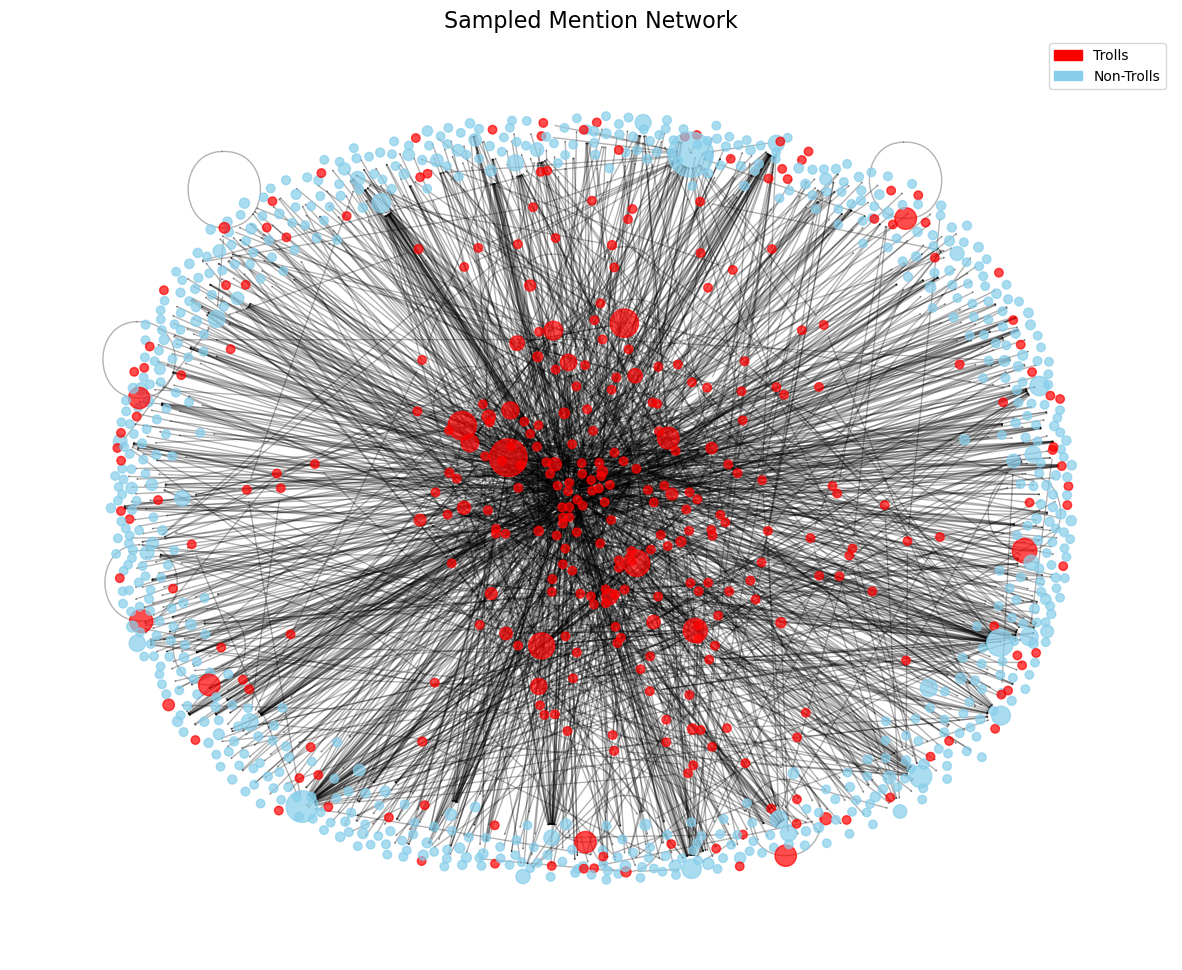

In [193]:
pos = nx.spring_layout(G_sample, k=0.3, seed=42)
communities = [G_sample.nodes[n]['community'] for n in G_sample.nodes]
colors = ['red' if G_sample.nodes[n]['troll'] else 'skyblue' for n in G_sample.nodes]
# legend

troll_patch = mpatches.Patch(color='red', label='Trolls')
non_troll_patch = mpatches.Patch(color='skyblue', label='Non-Trolls')

plt.figure(figsize=(15,12))
nx.draw_networkx_nodes(
    G_sample, pos,
    node_color=colors,
    node_size=[G_sample.nodes[n].get('pagerank',0)*50000 for n in G_sample.nodes],
    alpha=0.7
)
nx.draw_networkx_edges(G_sample, pos, alpha=0.3, arrowsize=1)

plt.title("Sampled Mention Network", fontsize=16)
plt.axis('off')
plt.legend(handles=[troll_patch, non_troll_patch])
plt.show()

C:\Users\jakub\AppData\Local\Temp\ipykernel_17928\2803758927.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_communities)


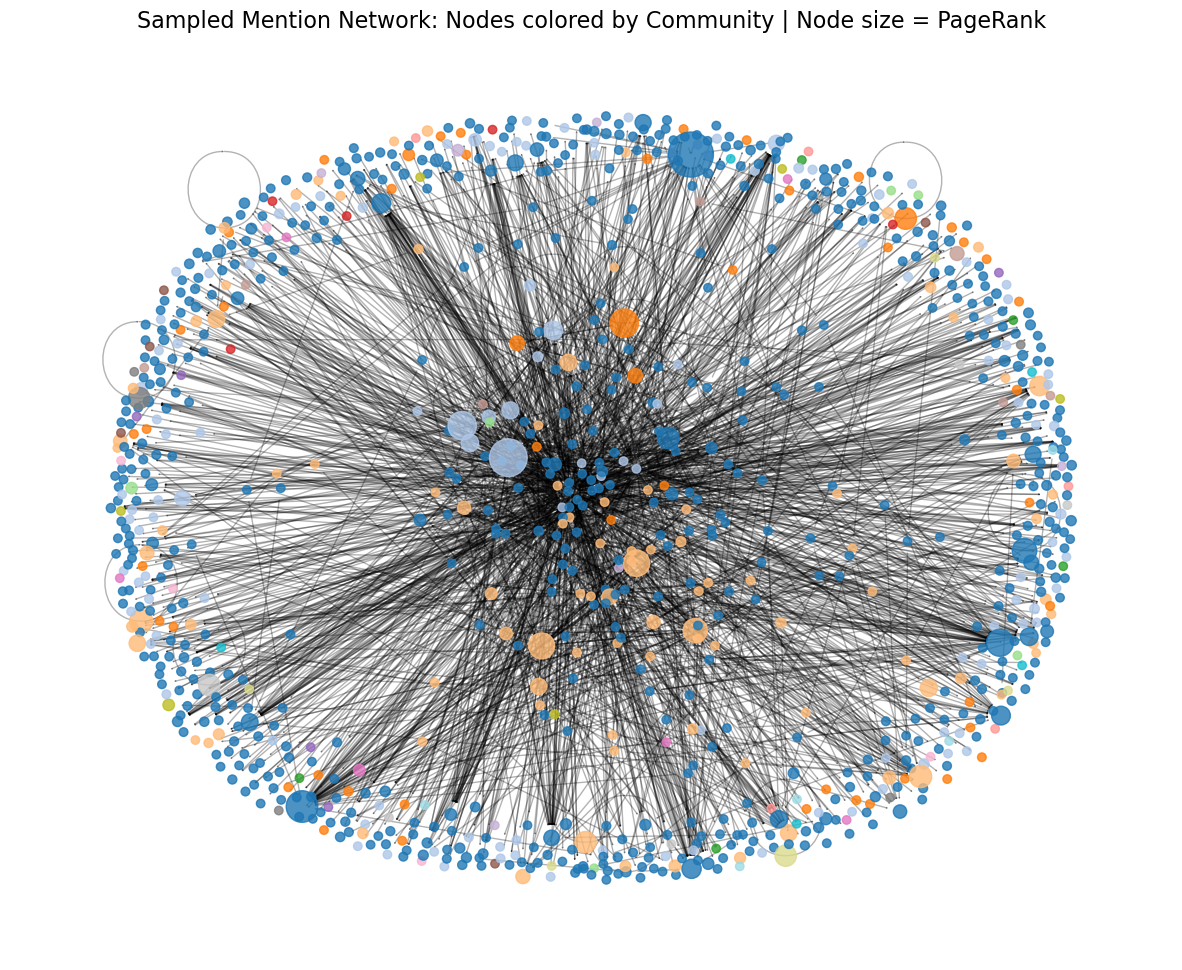

In [194]:
pos = nx.spring_layout(G_sample, k=0.3, seed=42)

communities = [G_sample.nodes[n]['community'] for n in G_sample.nodes]
num_communities = max(communities) + 1
cmap = cm.get_cmap('tab20', num_communities)

node_colors = [cmap(G_sample.nodes[n]['community']) for n in G_sample.nodes]

node_sizes = [G_sample.nodes[n].get('pagerank',0) * 50000 for n in G_sample.nodes]

plt.figure(figsize=(15,12))
nx.draw_networkx_nodes(
    G_sample, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.8
)
nx.draw_networkx_edges(G_sample, pos, alpha=0.3, arrowsize=1)

plt.title("Sampled Mention Network: Nodes colored by Community | Node size = PageRank", fontsize=16)
plt.axis('off')
plt.show()

In [197]:
num_nodes = G_sample.number_of_nodes()
num_edges = G_sample.number_of_edges()
density = nx.density(G_sample)

in_degrees = dict(G_sample.in_degree(weight='weight'))
out_degrees = dict(G_sample.out_degree(weight='weight'))
total_degrees = dict(G_sample.degree(weight='weight'))

avg_in_degree = np.mean(list(in_degrees.values()))
avg_out_degree = np.mean(list(out_degrees.values()))
avg_total_degree = np.mean(list(total_degrees.values()))
avg_clustering = nx.average_clustering(G_sample.to_undirected())

print("Sampled Mention Network Stats:")
print("Nodes:", num_nodes)
print("Edges:", num_edges)
print("Density:", density)
print("Avg in-degree:", avg_in_degree)
print("Avg out-degree:", avg_out_degree)
print("Avg total degree:", avg_total_degree)
print("Avg clustering coefficient:", avg_clustering)

deg_values = list(total_degrees.values())
print("\nDegree stats:")
print("Min:", np.min(deg_values))
print("Max:", np.max(deg_values))
print("Median:", np.median(deg_values))
print("Mean:", np.mean(deg_values))

try:
    degree_assortativity = nx.degree_assortativity_coefficient(G_sample.to_undirected())
    print("Degree assortativity (undirected):", degree_assortativity)
except Exception as e:
    print("Degree assortativity error:", e)

try:
    in_out_corr = nx.degree_pearson_correlation_coefficient(G_sample, x='in', y='out')
    print("In-degree / out-degree correlation:", in_out_corr)
except Exception as e:
    print("In/out-degree correlation error:", e)

Sampled Mention Network Stats:
Nodes: 1000
Edges: 1935
Density: 0.0019369369369369369
Avg in-degree: 3.358
Avg out-degree: 3.358
Avg total degree: 6.716
Avg clustering coefficient: 0.021252057783914598

Degree stats:
Min: 0
Max: 346
Median: 1.0
Mean: 6.716
Degree assortativity (undirected): -0.25186407034998204
In-degree / out-degree correlation: 0.1288172315379146


sparse network\
most users have very few connections\
some users are isolated\
some nodes are extremely active\
mentions rarely form triangles\
dissortative - high-degree nodes tend to connect to low-degree nodes\
weak positive correlation; users who mention many are only slightly more likely to be mentioned themselves.\
